# 08 · NER Exploration on the Harmonized Dataset

This notebook is an **exploration / sanity-check notebook**, not a harmonisation step.

It:
1. Loads a sample from the harmonized healthcare dataset.
2. Runs spaCy's general English `en_core_web_sm` NER model.
3. Extracts the entities and their labels.
4. Compares the detected entity strings with the existing `medical_entities` annotations.
5. Visualizes the most common entity types and a few examples.

**Important:** `en_core_web_sm` is a general-domain NER model. It is **not a biomedical NER model**, so poor recognition of drugs, diseases, symptoms, etc. is expected.

**Model:** `en_core_web_sm`
**Text fields:** `utterance` and `target_response`
**Purpose:** assess whether a general NER model is useful for validating/enriching the existing medical entity annotations.


## 0 · Imports & setup

### Configuration note

This notebook only **reads** the harmonized dataset. It does not modify the source parquet file. The NER results are exploratory and remain in memory unless you explicitly save them.

In [1]:
import ast
import json
import random
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings("ignore")

import pandas as pd
import spacy
from spacy import displacy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print(f"spaCy version : {spacy.__version__}")
print(f"pandas version: {pd.__version__}")


spaCy version : 3.8.15
pandas version: 3.0.5


## 1 · Load the harmonized dataset

In [2]:
from pathlib import Path

# Resolve paths relative to the notebook/project rather than assuming a specific
# current working directory.
CANDIDATE_PATHS = [
    Path("../data/processed/final/harmonized_healthcare_dataset.parquet"),
    Path("data/processed/final/harmonized_healthcare_dataset.parquet"),
    Path("../../data/processed/final/harmonized_healthcare_dataset.parquet"),
]

DATA_PATH = next((p.resolve() for p in CANDIDATE_PATHS if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find harmonized_healthcare_dataset.parquet. "
        "Update CANDIDATE_PATHS to match your project structure."
    )

df_full = pd.read_parquet(DATA_PATH)

required_cols = {
    "utterance",
    "target_response",
    "medical_entities",
    "source_dataset",
}
missing = required_cols - set(df_full.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing)}")

print(f"Dataset path : {DATA_PATH}")
print(f"Full dataset shape: {df_full.shape}")
df_full[list(required_cols)].head(3)


Dataset path : C:\Users\nirmi\Desktop\Capstone\data\processed\final\harmonized_healthcare_dataset.parquet
Full dataset shape: (270390, 24)


,medical_entities,utterance,target_response,source_dataset
0,[blood pressure],Does blood thinners increase blood pressure or...,Blood thinners do not directly increase blood ...,HealthChat
1,"[aspirin, blood pressure, heart rate]",Blood thinners do not directly increase blood ...,NaN,HealthChat
2,[],how can a vegan have a balanced diet which con...,It can be difficult for a vegan to obtain suff...,HealthChat


## 2 · Sample — 500 rows, stratified by source_dataset

In [ ]:
import numpy as np
import pandas as pd

SAMPLE_N = 500
RANDOM_SEED = 42

def stratified_sample(df, n, seed=42):
    """Return approximately n rows while preserving source proportions."""

    if n <= 0:
        raise ValueError("n must be > 0")

    if df.empty:
        return df.copy()

    counts = df["source_dataset"].value_counts()
    n = min(n, len(df))

    raw = counts / counts.sum() * n

    # FIX: use np.floor() instead of raw.floor()
    allocation = np.floor(raw).astype(int)

   
    if n >= len(counts):
        for src in counts.index:
            if allocation[src] == 0:
                allocation[src] = 1

   
    while allocation.sum() < n:

        remainders = raw - allocation

        valid = allocation.index[allocation < counts]

        if len(valid) == 0:
            break

        src = remainders[valid].idxmax()
        allocation[src] += 1


    while allocation.sum() > n:

        remainders = raw - allocation


        valid = allocation.index[allocation > 1]

        if len(valid) == 0:
            break

        src = remainders[valid].idxmin()
        allocation[src] -= 1


    frames = []

    for src, k in allocation.items():

        if k <= 0:
            continue

        subset = df[df["source_dataset"] == src]

        k = min(k, len(subset))

        frames.append(
            subset.sample(
                n=k,
                random_state=seed
            )
        )


    result = (
        pd.concat(frames, ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

    return result



df = stratified_sample(
    df_full,
    SAMPLE_N,
    RANDOM_SEED
)

print(f"Sample shape: {df.shape}")

print("\nSource distribution in sample:")
print(df["source_dataset"].value_counts())

print("\nSource distribution (%):")
print(
    df["source_dataset"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

assert len(df) <= SAMPLE_N

Sample shape: (500, 24)

Source distribution in sample:
source_dataset
MedDialog     415
MedQuAD        61
HealthChat     24
Name: count, dtype: int64

Source distribution (%):
source_dataset
MedDialog     83.0
MedQuAD       12.2
HealthChat     4.8
Name: proportion, dtype: float64


## 3 · Load the spaCy model

In [5]:
MODEL_NAME = "en_core_web_sm"

try:
    nlp = spacy.load(MODEL_NAME)
except OSError as exc:
    raise RuntimeError(
        f"spaCy model '{MODEL_NAME}' is not installed. "
        f"Install it in the environment with: python -m spacy download {MODEL_NAME}"
    ) from exc

if "ner" not in nlp.pipe_names:
    raise RuntimeError(f"'{MODEL_NAME}' does not contain an NER component.")

# Do NOT disable tok2vec: the NER component depends on it in spaCy's pipeline.
print("Pipeline:", nlp.pipe_names)
print("Entity types in en_core_web_sm:")
for label in nlp.get_pipe("ner").labels:
    print(f"  {label:12s} — {spacy.explain(label)}")


Pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
Entity types in en_core_web_sm:
  CARDINAL     — Numerals that do not fall under another type
  DATE         — Absolute or relative dates or periods
  EVENT        — Named hurricanes, battles, wars, sports events, etc.
  FAC          — Buildings, airports, highways, bridges, etc.
  GPE          — Countries, cities, states
  LANGUAGE     — Any named language
  LAW          — Named documents made into laws.
  LOC          — Non-GPE locations, mountain ranges, bodies of water
  MONEY        — Monetary values, including unit
  NORP         — Nationalities or religious or political groups
  ORDINAL      — "first", "second", etc.
  ORG          — Companies, agencies, institutions, etc.
  PERCENT      — Percentage, including "%"
  PERSON       — People, including fictional
  PRODUCT      — Objects, vehicles, foods, etc. (not services)
  QUANTITY     — Measurements, as of weight or distance
  TIME         — Times

## 4 · Run NER over the sample

We concatenate `utterance` + `target_response` into a single text per row so
the model sees the full exchange. We use `nlp.pipe` for efficiency.

In [6]:
def clean_text(value):
    """Convert a dataset value to a clean string, treating nulls as empty."""
    if value is None or pd.isna(value):
        return ""
    return str(value).strip()

def build_text(row):
    """Combine the available utterance and target response for exploration."""
    parts = []
    utterance = clean_text(row["utterance"])
    response = clean_text(row["target_response"])

    if utterance:
        parts.append(utterance)
    if response:
        parts.append(response)

    return " ".join(parts)

texts = df.apply(build_text, axis=1).tolist()

# Keep a configurable safety limit. Offsets below refer to this combined text.
MAX_TEXT_CHARS = 10_000
truncated_flags = [len(t) > MAX_TEXT_CHARS for t in texts]
texts = [t[:MAX_TEXT_CHARS] for t in texts]

print(f"Running NER on {len(texts)} texts …")
print(f"Texts truncated at {MAX_TEXT_CHARS:,} chars: {sum(truncated_flags)}")

# Keep tok2vec enabled because NER uses its representations.
# Disable only components that are not needed for NER.
with nlp.select_pipes(
    disable=["tagger", "parser", "attribute_ruler", "lemmatizer"]
):
    docs = list(nlp.pipe(texts, batch_size=32))

print("Done.")


Running NER on 500 texts …
Texts truncated at 10,000 chars: 0
Done.


## 5 · Collect results into a flat DataFrame

In [7]:
records = []

for i, doc in enumerate(docs):
    row = df.iloc[i]
    for ent in doc.ents:
        records.append({
            "row_idx": i,
            "source_dataset": row["source_dataset"],
            "entity_text": ent.text.strip(),
            "label": ent.label_,
            "label_desc": spacy.explain(ent.label_) or ent.label_,
            "start_char": ent.start_char,
            "end_char": ent.end_char,
            "text_truncated": truncated_flags[i],
        })

NER_COLUMNS = [
    "row_idx",
    "source_dataset",
    "entity_text",
    "label",
    "label_desc",
    "start_char",
    "end_char",
    "text_truncated",
]

ner_df = pd.DataFrame(records, columns=NER_COLUMNS)

print(f"Total entities extracted: {len(ner_df)}")
print(
    f"Unique entity types     : "
    f"{ner_df['label'].nunique() if not ner_df.empty else 0}"
)

if ner_df.empty:
    print("No entities were detected in the sample.")
else:
    display(ner_df.head(10))


Total entities extracted: 2877
Unique entity types     : 18


,row_idx,source_dataset,entity_text,label,label_desc,start_char,end_char,text_truncated
0,0,MedDialog,First,ORDINAL,"""first"", ""second"", etc.",83,88,False
1,0,MedDialog,Naproxen,ORG,"Companies, agencies, institutions, etc.",90,98,False
2,0,MedDialog,Acetaminophen,GPE,"Countries, cities, states",255,268,False
3,0,MedDialog,Naproxen,ORG,"Companies, agencies, institutions, etc.",298,306,False
4,1,MedDialog,Hope,PERSON,"People, including fictional",423,427,False
5,2,MedDialog,eighteen years old,DATE,Absolute or relative dates or periods,7,25,False
6,2,MedDialog,about two weeks ago,DATE,Absolute or relative dates or periods,30,49,False
7,2,MedDialog,about two weeks,DATE,Absolute or relative dates or periods,87,102,False
8,2,MedDialog,about a week and a half,DATE,Absolute or relative dates or periods,151,174,False
9,2,MedDialog,the last few days,DATE,Absolute or relative dates or periods,378,395,False


## 6 · Entity-type frequency

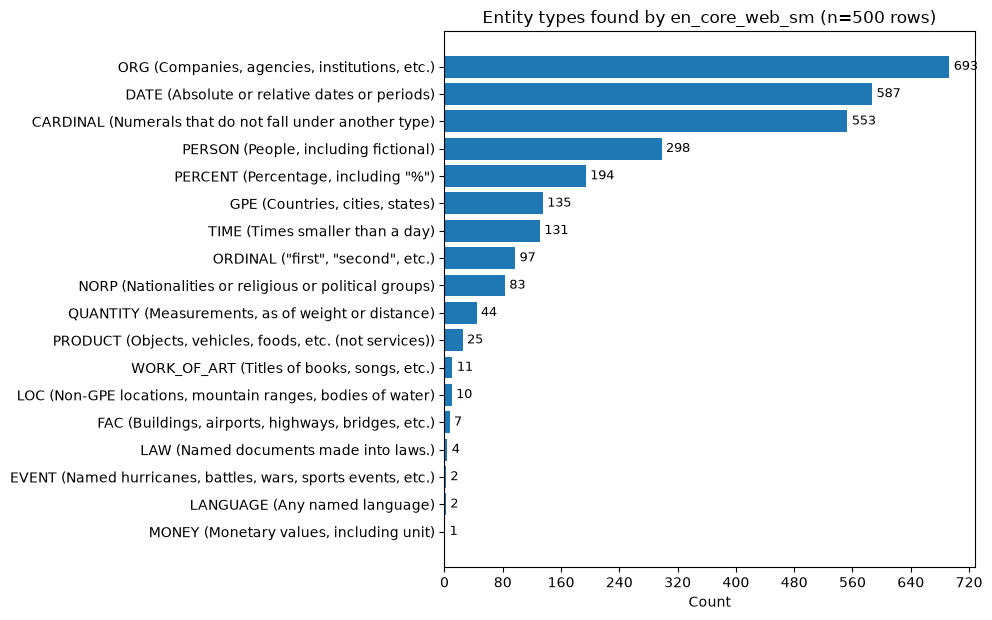

In [8]:
if ner_df.empty:
    print("No entities to plot.")
else:
    label_counts = (
        ner_df.groupby(["label", "label_desc"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(label_counts))))
    labels = label_counts["label"] + " (" + label_counts["label_desc"] + ")"
    bars = ax.barh(labels, label_counts["count"])

    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Entity types found by en_core_web_sm (n={len(df)} rows)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    pad = max(1, int(label_counts["count"].max() * 0.01))
    for bar in bars:
        ax.text(
            bar.get_width() + pad,
            bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())),
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


## 7 · Top-20 most frequent entity strings

In [9]:
if ner_df.empty:
    top_entities = pd.DataFrame(columns=["entity_text", "label", "count"])
    print("No entities detected.")
else:
    top_entities = (
        ner_df.groupby(["entity_text", "label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(20)
    )
    display(top_entities)


,entity_text,label,count
355,7.5%,PERCENT,71
117,2,CARDINAL,59
1311,first,ORDINAL,53
382,90%,PERCENT,45
1421,one,CARDINAL,43
8,1,CARDINAL,41
205,3,CARDINAL,39
307,50%,PERCENT,38
1538,two,CARDINAL,24
529,Chat,NORP,22


## 8 · Compare with existing `medical_entities` column

The harmonisation pipeline already extracted a list of medical terms per row.
Here we check the overlap: for each row, how many of the spaCy entities also
appear in the pre-existing list (case-insensitive)?

In [10]:
def normalize_entity(text):
    """Normalize entity strings for case-insensitive, whitespace-tolerant matching."""
    return " ".join(str(text).casefold().split())

def parse_medical_entities(val):
    """Safely parse medical_entities from list/tuple/set/array/string/JSON/null."""
    if val is None:
        return set()

    # Handle scalar nulls without applying pd.isna to a list-like value.
    if not isinstance(val, (list, tuple, set)):
        try:
            if pd.isna(val):
                return set()
        except (TypeError, ValueError):
            pass

    if isinstance(val, (list, tuple, set)):
        return {
            normalize_entity(x)
            for x in val
            if x is not None and normalize_entity(x)
        }

    text = str(val).strip()
    if not text or text.casefold() in {"nan", "none", "null"}:
        return set()

    # First try Python/JSON list syntax.
    for parser in (ast.literal_eval, json.loads):
        try:
            parsed = parser(text)
            if isinstance(parsed, (list, tuple, set)):
                return {
                    normalize_entity(x)
                    for x in parsed
                    if x is not None and normalize_entity(x)
                }
        except (ValueError, SyntaxError, TypeError, json.JSONDecodeError):
            pass

    # Fall back to treating the scalar itself as one annotation.
    return {normalize_entity(text)}

overlap_records = []

for i, doc in enumerate(docs):
    row = df.iloc[i]

    spacy_ents = {
        normalize_entity(ent.text)
        for ent in doc.ents
        if normalize_entity(ent.text)
    }
    existing = parse_medical_entities(row["medical_entities"])

    overlap = spacy_ents & existing

    overlap_records.append({
        "row_idx": i,
        "source_dataset": row["source_dataset"],
        "n_spacy": len(spacy_ents),
        "n_existing": len(existing),
        "n_overlap": len(overlap),
        "spacy_only": sorted(spacy_ents - existing),
        "existing_only": sorted(existing - spacy_ents),
        "overlap_entities": sorted(overlap),
    })

overlap_df = pd.DataFrame(overlap_records)

print("Overlap summary (across all sampled rows):")
display(
    overlap_df[
        ["n_spacy", "n_existing", "n_overlap"]
    ].describe().round(2)
)


Overlap summary (across all sampled rows):


,n_spacy,n_existing,n_overlap
count,500.00,500.00,500.00
mean,4.87,0.47,0.01
std,4.26,0.50,0.12
min,0.00,0.00,0.00
25%,2.00,0.00,0.00
50%,4.00,0.00,0.00
75%,7.00,1.00,0.00
max,32.00,1.00,1.00


Rows with at least 1 exact normalized overlap: 7 / 500

Mean coverage among rows with at least one existing annotation:
existing_coverage     0.03
spacy_coverage       0.008
dtype: object


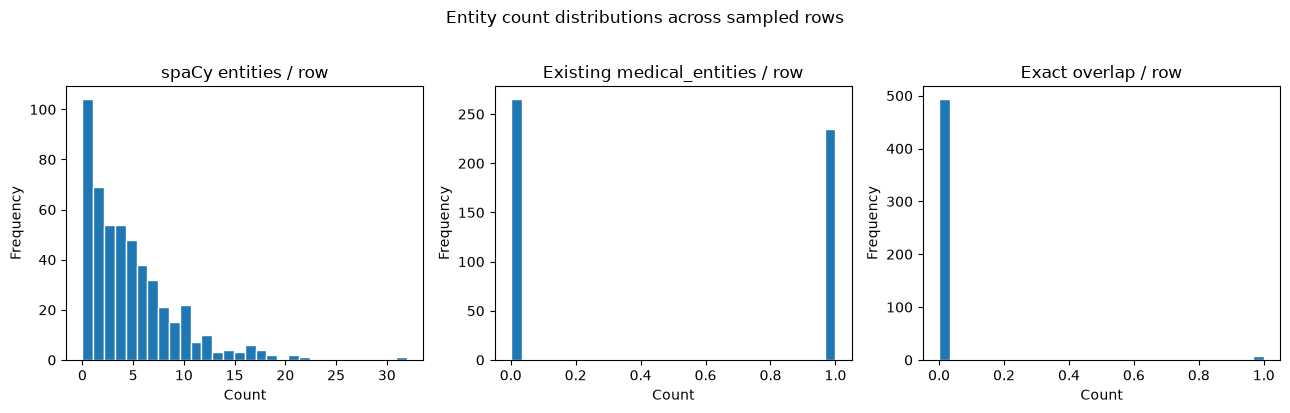


Note: exact string overlap is only a sanity-check. It is not entity-level precision/recall because the two systems use different label schemes and the existing column has no span annotations.


In [11]:
matched = overlap_df[overlap_df["n_overlap"] > 0]
print(f"Rows with at least 1 exact normalized overlap: {len(matched)} / {len(overlap_df)}")

# Row-level coverage diagnostics.
overlap_df["existing_coverage"] = (
    overlap_df["n_overlap"]
    .div(overlap_df["n_existing"].replace(0, pd.NA))
)
overlap_df["spacy_coverage"] = (
    overlap_df["n_overlap"]
    .div(overlap_df["n_spacy"].replace(0, pd.NA))
)

print("\nMean coverage among rows with at least one existing annotation:")
print(
    overlap_df.loc[overlap_df["n_existing"] > 0, 
                   ["existing_coverage", "spacy_coverage"]]
    .mean()
    .round(3)
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ["n_spacy", "n_existing", "n_overlap"],
    ["spaCy entities / row", "Existing medical_entities / row", "Exact overlap / row"],
):
    overlap_df[col].plot.hist(bins=30, ax=ax, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Count")

plt.suptitle("Entity count distributions across sampled rows", y=1.02)
plt.tight_layout()
plt.show()

print(
    "\nNote: exact string overlap is only a sanity-check. "
    "It is not entity-level precision/recall because the two systems use "
    "different label schemes and the existing column has no span annotations."
)


## 9 · displaCy visualisation — 3 random rows

Render the NER annotations inline so we can eyeball quality.

In [12]:
rich_indices = [i for i, doc in enumerate(docs) if len(doc.ents) >= 3]

sample_indices = random.Random(RANDOM_SEED).sample(
    rich_indices, min(3, len(rich_indices))
)

if not sample_indices:
    print("No rows with at least 3 detected entities.")
else:
    for idx in sample_indices:
        row = df.iloc[idx]
        print(f"\n--- Row {idx} | source: {row['source_dataset']} ---")
        print(f"UTTERANCE: {clean_text(row['utterance'])[:300]}")
        print(f"TARGET RESPONSE: {clean_text(row['target_response'])[:300]}")
        print(f"EXISTING medical_entities: {row['medical_entities']}")
        print(f"TRUNCATED FOR NER: {truncated_flags[idx]}")
        displacy.render(docs[idx], style="ent", jupyter=True)



--- Row 480 | source: MedDialog ---
UTTERANCE: Hi!. My wife aged 41 years, has some allergy which result in lots of sneezing. She often taks Cetrizine medicine. Recently, we are seeing lots of swelling on the right side of her face. As per the suggestion of a doctor, we went through blood, urine, Thyriod and sonography test and all the reports a
TARGET RESPONSE: Hello, Welcome to Chat Doctor, As you are wife is having some allergic manifestations for which she is taking cetirizine medication which was relieving the symptoms, she should be very careful with the symptoms as it may be dangerous to the life. I would suggest her to undergo absolute eosinophil co
EXISTING medical_entities: []
TRUNCATED FOR NER: False



--- Row 87 | source: MedDialog ---
UTTERANCE: Hi I have understood your query well. According to your blood pressure u only have increased diastolic blood pressure. 128 which is systolic is normal. U can start doing exercise and loose weight plus decrease intake of sodium containing food like salt, bakery items, packed food, junk food, cold Cha
TARGET RESPONSE: 
EXISTING medical_entities: ['blood pressure']
TRUNCATED FOR NER: False



--- Row 16 | source: HealthChat ---
UTTERANCE: I'm not a doctor, but I can suggest some general treatments for each of these conditions. Remember to consult with a healthcare professional for personalized advice and appropriate treatment. 

1. Otitis externa (infection of the outer ear):
   - Cleaning and draining the ear canal
   - Topical anti
TARGET RESPONSE: 
EXISTING medical_entities: ['antibiotic' 'inflammation' 'nausea' 'pain']
TRUNCATED FOR NER: False


## 10 · Observations & next steps

### What this notebook can establish

- `en_core_web_sm` detects **general-domain** entity types such as PERSON, ORG, DATE,
  CARDINAL, GPE, etc.
- It should **not** be treated as a biomedical ground-truth annotator.
- Exact overlap with `medical_entities` is only a rough consistency signal because
  the two annotation systems have different objectives and label schemas.
- The existing `medical_entities` field contains entity strings but not character spans,
  so proper entity-level precision/recall cannot be computed from this column alone.

### Recommended next steps

1. Use a biomedical NER model such as scispaCy / BC5CDR or another validated
   biomedical model if the goal is medical entity recognition.
2. Keep this notebook as an **exploration/diagnostic notebook**, not as a replacement
   for the harmonisation annotations.
3. If you want quantitative NER evaluation, create a manually reviewed gold sample
   with entity spans and labels.
4. If the goal is to enrich `medical_entities`, compare biomedical NER predictions
   against the existing annotations and deduplicate/normalize before adding anything.
5. Do not overwrite the harmonized dataset from this notebook; save exploratory
   outputs separately.
